# SGD vs. Adam vs. AamdW

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

import torch
import torch.nn as nn
import torch.nn.functional as F 

## pre-exercise example

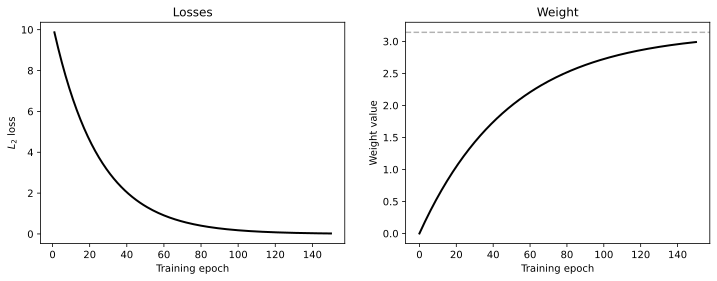

In [3]:
# initialize weight value
w = torch.tensor([0.], requires_grad=True)

# target value
target = torch.tensor([torch.pi])

# learning rate
lr = .01

# create the optimizer
optimizer = torch.optim.SGD([w], lr=lr)

# number of training iterations
num_iters = 150

# initialize results matrices
all_losses = np.zeros(num_iters)
all_weights = np.zeros(num_iters+1)
all_weights[0] = w.item() # initial value

# training loop
for i in range(num_iters):
    # train the weight
    optimizer.zero_grad()
    loss = (w - target) ** 2
    loss.backward()
    optimizer.step()
    # store the loss and update the weight value
    all_losses[i] = loss.item()
    all_weights[i+1] = w.item()

# visualize
_, axs = plt.subplots(1, 2, figsize=(12,4))

axs[0].plot(range(1, num_iters+1), all_losses, 'k', linewidth=2)
axs[1].plot(range(0, num_iters+1), all_weights, 'k', linewidth=2)

axs[0].set(title='Losses',
           ylabel='$L_2$ loss',
           xlabel='Training epoch')
axs[1].set(title='Weight',
           ylabel='Weight value',
           xlabel='Training epoch')
axs[1].axhline(target, linestyle='--', color=[.7,.7,.7], label='Target')

## The optimizer competition

In [5]:
# initialize weight value
wSGD   = torch.tensor([2.], requires_grad=True)
wAdam  = torch.tensor([2.], requires_grad=True)
wAdamW = torch.tensor([2.], requires_grad=True)

# target value
target = torch.tensor([5.])

# learning rates
learningrateSGD = .05
learningrateAdm = .05

# create the optimizers
optimizerSGD   = torch.optim.SGD([wSGD],    lr=learningrateSGD)
optimizerAdam  = torch.optim.Adam([wAdam],  lr=learningrateAdm)
optimizerAdamW = torch.optim.AdamW([wAdamW],lr=learningrateAdm)

# number of training iterations
num_iters = 100

# initialize results matrices
all_losses  = np.zeros((3,num_iters))
all_weights = np.zeros((3,num_iters+1))
all_weights[:,0] = wSGD.item()

# training loop
for i in range(num_iters):
    # train the sgd weight
    optimizerSGD.zero_grad()
    lossSGD = (wSGD - target) ** 2
    lossSGD.backward()
    optimizerSGD.step()

    # train with Adam
    optimizerAdam.zero_grad()
    lossAdam = (wAdam - target) ** 2
    lossAdam.backward()
    optimizerAdam.step()

    # train with AdamW
    optimizerAdamW.zero_grad()
    lossAdamW = (wAdamW - target) ** 2
    lossAdamW.backward()
    optimizerAdamW.step()

    # store losses and update weights
    all_losses[0, i] = lossSGD.item()
    all_losses[1, i] = lossAdam.item()
    all_losses[2, i] = lossAdamW.item()

    all_weights[0, i+1] = wSGD.item()
    all_weights[1, i+1] = wAdam.item()
    all_weights[2, i+1] = wAdamW.item()

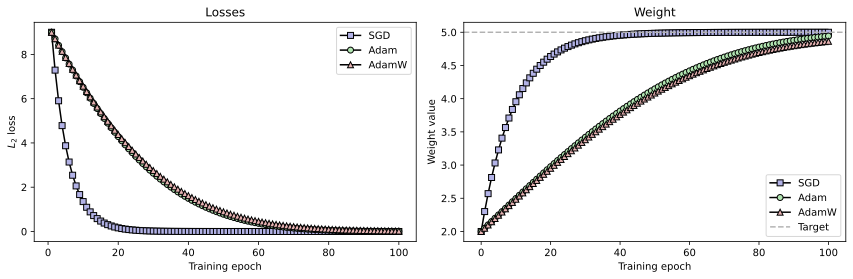

In [6]:
_, axs = plt.subplots(1,2,figsize=(12,4))

# labels and markers
optimlabels = [ 'SGD','Adam','AdamW' ]
markercols = [ [.7,.7,.9],[.7,.9,.7],[.9,.7,.7] ]
shapes = 'so^'


# loop over the optimizers and plot
for i in range(3):

    # plot the losses
    axs[0].plot(range(1,num_iters+1),all_losses[i,:],'k',marker=shapes[i],
                markerfacecolor=markercols[i],label=optimlabels[i])

    # plot the weight
    axs[1].plot(range(0,num_iters+1),all_weights[i,:],'k',marker=shapes[i],
                markerfacecolor=markercols[i],label=optimlabels[i])


axs[0].set(title='Losses', ylabel='$L_2$ loss', xlabel='Training epoch')
axs[1].set(title='Weight', ylabel='Weight value', xlabel='Training epoch')
axs[1].axhline(target, linestyle='--', color=[.7,.7,.7], label='Target')

for a in axs: a.legend()

plt.tight_layout()
plt.show()

## Adjust the learning rates

In [8]:
# initialize weight value
wSGD   = torch.tensor([2.], requires_grad=True)
wAdam  = torch.tensor([2.], requires_grad=True)
wAdamW = torch.tensor([2.], requires_grad=True)

# target value
target = torch.tensor([5.])

# learning rates
learningrateSGD = .04
learningrateAdm = .1

# create the optimizers
optimizerSGD   = torch.optim.SGD([wSGD],    lr=learningrateSGD)
optimizerAdam  = torch.optim.Adam([wAdam],  lr=learningrateAdm)
optimizerAdamW = torch.optim.AdamW([wAdamW],lr=learningrateAdm)

# number of training iterations
num_iters = 100

# initialize results matrices
all_losses  = np.zeros((3,num_iters))
all_weights = np.zeros((3,num_iters+1))
all_weights[:,0] = wSGD.item()

# training loop
for i in range(num_iters):
    # train the sgd weight
    optimizerSGD.zero_grad()
    lossSGD = (wSGD - target) ** 2
    lossSGD.backward()
    optimizerSGD.step()

    # train with Adam
    optimizerAdam.zero_grad()
    lossAdam = (wAdam - target) ** 2
    lossAdam.backward()
    optimizerAdam.step()

    # train with AdamW
    optimizerAdamW.zero_grad()
    lossAdamW = (wAdamW - target) ** 2
    lossAdamW.backward()
    optimizerAdamW.step()

    # store losses and update weights
    all_losses[0, i] = lossSGD.item()
    all_losses[1, i] = lossAdam.item()
    all_losses[2, i] = lossAdamW.item()

    all_weights[0, i+1] = wSGD.item()
    all_weights[1, i+1] = wAdam.item()
    all_weights[2, i+1] = wAdamW.item()

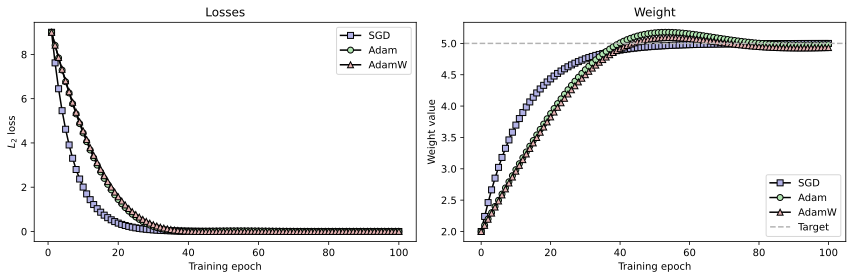

In [9]:
_, axs = plt.subplots(1,2,figsize=(12,4))

# labels and markers
optimlabels = [ 'SGD','Adam','AdamW' ]
markercols = [ [.7,.7,.9],[.7,.9,.7],[.9,.7,.7] ]
shapes = 'so^'


# loop over the optimizers and plot
for i in range(3):

    # plot the losses
    axs[0].plot(range(1,num_iters+1),all_losses[i,:],'k',marker=shapes[i],
                markerfacecolor=markercols[i],label=optimlabels[i])

    # plot the weight
    axs[1].plot(range(0,num_iters+1),all_weights[i,:],'k',marker=shapes[i],
                markerfacecolor=markercols[i],label=optimlabels[i])


axs[0].set(title='Losses', ylabel='$L_2$ loss', xlabel='Training epoch')
axs[1].set(title='Weight', ylabel='Weight value', xlabel='Training epoch')
axs[1].axhline(target, linestyle='--', color=[.7,.7,.7], label='Target')

for a in axs: a.legend()

plt.tight_layout()
plt.show()

## Without resetting gradients

In [10]:
# initialize weight value
wSGD   = torch.tensor([2.], requires_grad=True)
wAdam  = torch.tensor([2.], requires_grad=True)
wAdamW = torch.tensor([2.], requires_grad=True)

# target value
target = torch.tensor([5.])

# learning rates
learningrateSGD = .04
learningrateAdm = .1

# create the optimizers
optimizerSGD   = torch.optim.SGD([wSGD],    lr=learningrateSGD)
optimizerAdam  = torch.optim.Adam([wAdam],  lr=learningrateAdm)
optimizerAdamW = torch.optim.AdamW([wAdamW],lr=learningrateAdm)

# number of training iterations
num_iters = 30

# initialize results matrices
all_losses  = np.zeros((3,num_iters))
all_weights = np.zeros((3,num_iters+1))
all_weights[:,0] = wSGD.item()

# training loop
for i in range(num_iters):
    # train the sgd weight
    optimizerSGD.zero_grad()
    lossSGD = (wSGD - target) ** 2
    lossSGD.backward()
    optimizerSGD.step()

    # train with Adam
    optimizerAdam.zero_grad()
    lossAdam = (wAdam - target) ** 2
    lossAdam.backward()
    optimizerAdam.step()

    # train with AdamW
    # optimizerAdamW.zero_grad()
    lossAdamW = (wAdamW - target) ** 2
    lossAdamW.backward()
    optimizerAdamW.step()

    print(f'{wAdam.grad.item():7.3f} {wAdamW.grad.item():7.3f}')

    # store losses and update weights
    all_losses[0, i] = lossSGD.item()
    all_losses[1, i] = lossAdam.item()
    all_losses[2, i] = lossAdamW.item()

    all_weights[0, i+1] = wSGD.item()
    all_weights[1, i+1] = wAdam.item()
    all_weights[2, i+1] = wAdamW.item()

 -6.000  -6.000
 -5.800 -11.804
 -5.600 -17.419
 -5.401 -22.846
 -5.202 -28.085
 -5.004 -33.134
 -4.806 -37.992
 -4.610 -42.657
 -4.414 -47.126
 -4.221 -51.398
 -4.028 -55.470
 -3.838 -59.341
 -3.649 -63.007
 -3.463 -66.467
 -3.279 -69.719
 -3.098 -72.761
 -2.920 -75.590
 -2.744 -78.205
 -2.572 -80.605
 -2.404 -82.787
 -2.239 -84.750
 -2.078 -86.493
 -1.921 -88.014
 -1.769 -89.313
 -1.621 -90.387
 -1.478 -91.237
 -1.340 -91.862
 -1.207 -92.260
 -1.079 -92.432
 -0.956 -92.377
